# NOTEBOOK PARA LA TRANSFORMACIÓN DE DATOS UNIDADES DE PROYECTO - INFRAESTRUCTURA: TESTING

### Importaciones necesarias

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

### Función para capitalizar Texto

In [2]:
def capitalizar_texto(texto):
    """
    Convierte un texto a minúsculas y deja en mayúscula solo la primera letra de cada palabra.
    Maneja valores None y retorna None si el input es None.
    """
    if texto is None or pd.isna(texto):
        return None
    return str(texto).title()

### Función para conectarse a Firebase

In [3]:
from pathlib import Path

project_root = Path(r"a:\programing_workspace\proyectos_cali_alcaldia_etl")

# Credenciales del proyecto Firebase (calitrack-44403)
credential_candidates = [
    project_root / "target-credentials-old-calitrack.json",
    project_root / "target-credentials.json",
]


In [4]:
import firebase_admin
from firebase_admin import credentials, firestore
from pathlib import Path
from google.api_core.exceptions import PermissionDenied

def conectar_firebase_firestore(project_id="calitrack-44403", credential_paths=None):
    global cred, db

    try:
        if credential_paths is None:
            credential_paths = globals().get("credential_candidates", [])

        if "cred" not in globals() or cred is None:
            cred = None
            for p in credential_paths:
                p = Path(p)
                if p.exists():
                    cred = credentials.Certificate(str(p))
                    break
            if cred is None:
                raise FileNotFoundError("No se encontró un archivo de credenciales válido.")

        if not firebase_admin._apps:
            firebase_admin.initialize_app(cred, {"projectId": project_id})

        db = firestore.client()

        # Verificación de conexión
        _ = list(db.collections())
        print(f"Conexión Firebase (Firestore) lista para el proyecto: {project_id}")
        return db

    except PermissionDenied as e:
        if "SERVICE_DISABLED" in str(e):
            print(
                "Firestore API está deshabilitada para este proyecto. "
                "Actívala en GCP y vuelve a intentar en unos minutos."
            )
        else:
            print(f"Permiso denegado en Firestore: {e}")
        return None

    except Exception as e:
        print(f"No fue posible conectar con Firestore: {e}")
        return None

db = conectar_firebase_firestore()


Conexión Firebase (Firestore) lista para el proyecto: calitrack-44403


### Función para obtener última upid

In [5]:
import re

def obtener_ultima_upid(db_client=None, collection_name="unidades_proyecto", campo_upid="upid"):
    """
    Busca la UPID más alta por sufijo numérico real (no orden lexicográfico).
    Soporta variantes de nombre de campo: upid / UPID.
    """
    if db_client is None:
        db_client = globals().get("db")

    if db_client is None:
        print("No hay cliente Firestore disponible (db).")
        return None

    ultima_upid = None
    max_num = -1

    try:
        for doc in db_client.collection(collection_name).stream():
            data = doc.to_dict() or {}

            # Intenta leer el campo principal y variantes comunes
            upid = data.get(campo_upid)
            if not upid:
                upid = data.get("UPID") or data.get("upid")

            if not upid:
                continue

            upid_str = str(upid).strip()

            # Extrae el último bloque numérico de la cadena
            nums = re.findall(r"\d+", upid_str)
            if not nums:
                continue

            n = int(nums[-1])
            if n > max_num:
                max_num = n
                ultima_upid = upid_str

        return ultima_upid

    except Exception as e:
        print(f"Error al leer la colección '{collection_name}': {e}")
        return None


ultima_upid = obtener_ultima_upid()
print("Última UPID:", ultima_upid)


Última UPID: UNP-1516


## DATOS 2024

In [6]:
gdf = gpd.read_file("app_inputs\\unidades_proyecto_input\\Infraestructura_2024.shp")

In [7]:
gdf

,Id_1,FID_1,Dirección,Barrio,Comuna,Tipo_Infra,Tipo_Int_1,Tipo_Mezcl,Tipo_Grupo,Longitud,...,Y_INICIA_1,X_FINAL_1,Y_FINAL_1,F__AVANCE,ESTADO,BP,Nompre_BP,BPIN,VALOR_INTE,geometry
0,1,0,CALLE 44 BIS ENTRE CARRERAS 6 Y 7,LA ESMERALDA,COMUNA 4,VIA LOCAL,RECARPETEO,MEZCLA CALIENTE,GRUPO OPERATIVO,121.000000,...,3.459911,-76.506156,3.458810,"100,00%",FINALIZADO,BP26004834,Conservación del estado de la malla vial de Sa...,2.023760e+12,"$ 91.233.179,26","LINESTRING Z (-76.50648 3.45991 0, -76.50647 3..."
1,2,1,CARRERA 7A BIS ENTRE CALLES 82 Y 84,ALFONSO LOPEZ P. 1A ETAPA,COMUNA 7,VIA LOCAL,RECARPETEO,MEZCLA CALIENTE,GRUPO OPERATIVO,147.000000,...,3.466028,-76.477944,3.466440,"100,00%",FINALIZADO,BP26004834,Conservación del estado de la malla vial de Sa...,2.023760e+12,"$ 110.837.002,90","LINESTRING Z (-76.47927 3.46603 0, -76.47794 3..."
2,4,2,CALLE 38N ENTRE CARRERAS 5N Y 7N,UNIDAD RESIDENCIAL BUENO MADRID,COMUNA 4,VIA LOCAL,RECARPETEO,MEZCLA CALIENTE,GRUPO OPERATIVO,128.000000,...,3.469494,-76.515847,3.468529,"100,00%",FINALIZADO,BP26004834,Conservación del estado de la malla vial de Sa...,2.023760e+12,"$ 96.511.131,78","LINESTRING Z (-76.51667 3.46949 0, -76.51585 3..."
3,5,3,CARRERA 41 ENTRE CALLES 41C Y 42,ANTONIO NARIÑO,COMUNA 16,VIA LOCAL,RECARPETEO,MEZCLA CALIENTE,GRUPO OPERATIVO,91.000000,...,3.413809,-76.507405,3.413162,"100,00%",FINALIZADO,BP26004239,Rehabilitación de vías en la zona urbana y rur...,2.022760e+12,"$ 68.613.382,75","LINESTRING Z (-76.50802 3.41381 0, -76.5074 3...."
4,6,4,AVENIDA 5 OESTE,TERRON COLORADO,COMUNA 1,VIA COLECTORA,RECARPETEO,MEZCLA CALIENTE,GRUPO OPERATIVO,7.600000,...,3.454394,-76.553468,3.454424,"100,00%",FINALIZADO,BP26004834,Conservación del estado de la malla vial de Sa...,2.023760e+12,"$ 5.730.348,45","LINESTRING Z (-76.55402 3.45439 0, -76.55347 3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,0,20,DIAGONAL 24ª ENTRE TV. 25 Y 29,20 de Julio,11,NO REPORTADO,None,NO REPORTADO,PRESUPUESTO PARTICIPATIVO URBANO,164.168835,...,0.000000,-76.513140,3.434177,"100,00%",FINALIZADO,BP26003972,Mantenimiento DE LA MALLA VIAL DE LA COMUNA 11...,2.021760e+12,"$ 252.003.221,00","LINESTRING Z (-76.51226 3.43537 0, -76.51314 3..."
308,0,21,CALLE 72 F ENTRE CARRERA 8 N Y CARRERA 9 N,Ciudadela Floralia,6,NO REPORTADO,None,NO REPORTADO,PRESUPUESTO PARTICIPATIVO URBANO,110.459428,...,0.000000,-76.496943,3.495069,"100,00%",FINALIZADO,BP26003969,Mantenimiento de la malla vial de la comuna 6 ...,2.021760e+12,"$ 146.580.547,00","LINESTRING Z (-76.49781 3.49555 0, -76.49694 3..."
309,0,22,CARRERA 1 A 13 ENTRE CALLE 73 Y CALLE 73 A,San Luis,6,NO REPORTADO,None,NO REPORTADO,PRESUPUESTO PARTICIPATIVO URBANO,76.471581,...,0.000000,-76.485082,3.481547,"100,00%",FINALIZADO,BP26003969,Mantenimiento de la malla vial de la comuna 6 ...,2.021760e+12,"$ 94.447.922,00","LINESTRING Z (-76.48443 3.48177 0, -76.48476 3..."
310,0,23,CALLE 74 A ENTRE CARRERA 11 Y CARRERA 15,Urbanización El Angel del Hogar,7,NO REPORTADO,None,NO REPORTADO,PRESUPUESTO PARTICIPATIVO URBANO,121.782926,...,0.000000,-76.481548,3.447386,"100,00%",FINALIZADO,BP26003970,Mantenimiento de vías en la comuna 7 de Santia...,2.021760e+12,"$ 140.796.000,00","LINESTRING Z (-76.48169 3.44629 0, -76.48155 3..."


In [8]:
gdf.rename(columns={'Dirección':'direccion', 
                    'Barrio':'barrio_vereda',
                    'Comuna':'comuna_corregimiento',
                    'Año':'anio',
                    'BPIN':'bpin',
                    'BP':'bp',
                    'VALOR_INTE':'presupuesto_base',
                    'Longitud':'cantidad',
                    'ESTADO':'estado',
                    'Tipo_Int_1':'tipo_intervencion',
                    'F__AVANCE':'avance_obra',
                    'Tipo_Grupo':'identificador',
                    'Tipo_Infra':'nombre_up',
                    'Tipo_Mezcl':'nombre_up_detalle'}
           , inplace=True)

In [9]:
gdf.drop(columns=['X_INICIA_1', 'Y_INICIA_1', 'X_FINAL_1', 'Y_FINAL_1', 'Nompre_BP','Id_1','FID_1','barrio_vereda', 'comuna_corregimiento'], inplace=True)

In [10]:
gdf[['referencia_proceso', 'referencia_contrato', 'tipo_equipamiento','fuente_financiacion',
    'unidad','fecha_inicio', 'fecha_fin', 'fecha_inauguracion','plataforma','url_proceso','clase_up',
    'descripcion_intervencion', 'observaciones','nombre_centro_gestor']] = None

In [11]:
gdf.columns

Index(['direccion', 'nombre_up', 'tipo_intervencion', 'nombre_up_detalle',
       'identificador', 'cantidad', 'anio', 'avance_obra', 'estado', 'bp',
       'bpin', 'presupuesto_base', 'geometry', 'referencia_proceso',
       'referencia_contrato', 'tipo_equipamiento', 'fuente_financiacion',
       'unidad', 'fecha_inicio', 'fecha_fin', 'fecha_inauguracion',
       'plataforma', 'url_proceso', 'clase_up', 'descripcion_intervencion',
       'observaciones', 'nombre_centro_gestor'],
      dtype='object')

In [12]:
gdf['unidad'] = 'm'
gdf['tipo_equipamiento'] = 'Vías'
gdf['clase_up'] = 'Obra vial'
gdf['nombre_centro_gestor'] = 'Secretaría de Infraestructura'

In [13]:
gdf['tipo_intervencion'] = gdf['tipo_intervencion'].apply(capitalizar_texto)
gdf['nombre_up'] = gdf['nombre_up'].apply(capitalizar_texto)
gdf['nombre_up_detalle'] = gdf['nombre_up_detalle'].apply(capitalizar_texto)
gdf['identificador'] = gdf['identificador'].apply(capitalizar_texto)
gdf['estado'] = gdf['estado'].apply(capitalizar_texto)
gdf['direccion'] = gdf['direccion'].apply(capitalizar_texto)

In [14]:
gdf['nombre_up'] = gdf['nombre_up'].replace('No Reportado', 'Vía Local')
gdf['nombre_up'] = gdf['nombre_up'].str.replace('Via', 'Vía')
gdf['estado']='Terminado'
gdf['avance_obra'] = gdf['avance_obra'].str.replace('%', '').str.replace(',', '.').astype(float).round(2)
gdf['cantidad'] = pd.to_numeric(gdf['cantidad'], errors='coerce').round(2)
gdf['avance_obra'] = pd.to_numeric(gdf['avance_obra'], errors='coerce').round(2)
gdf['presupuesto_base'] = gdf['presupuesto_base'].astype(str).str.replace('$', '').str.replace('.', '').str.replace(',', '.').astype(float).round(2)
gdf['tipo_intervencion'] = gdf['tipo_intervencion'].fillna('Pavimento')
gdf['anio'] = gdf['anio'].astype(int)


## INTERSECCIÓN GEOGRÁFICA DATOS 2024

In [15]:
# Cargar la capa de barrios y veredas
barrios_veredas = gpd.read_file("basemaps\\barrios_veredas.geojson")

# Asegurar que ambos GeoDataFrames tengan el mismo CRS
if gdf.crs != barrios_veredas.crs:
    barrios_veredas = barrios_veredas.to_crs(gdf.crs)

# Realizar la intersección espacial
gdf_intersected = gpd.sjoin(gdf, barrios_veredas[['barrio_vereda', 'geometry']], how='left', predicate='intersects')

# Si hay duplicados por intersecciones múltiples, mantener solo la primera coincidencia
gdf_intersected = gdf_intersected.drop_duplicates(subset=gdf.columns.tolist(), keep='first')

# Actualizar el GeoDataFrame original con la columna barrio_vereda
gdf['barrio_vereda'] = gdf_intersected['barrio_vereda'].values

In [16]:
# Cargar la capa de comunas y corregimientos
comunas_corregimientos = gpd.read_file("basemaps\\comunas_corregimientos.geojson")

# Asegurar que ambos GeoDataFrames tengan el mismo CRS
if gdf.crs != comunas_corregimientos.crs:
    comunas_corregimientos = comunas_corregimientos.to_crs(gdf.crs)

# Realizar la intersección espacial
gdf_intersected_comunas = gpd.sjoin(gdf, comunas_corregimientos[['comuna_corregimiento', 'geometry']], how='left', predicate='intersects')

# Si hay duplicados por intersecciones múltiples, mantener solo la primera coincidencia
gdf_intersected_comunas = gdf_intersected_comunas.drop_duplicates(subset=gdf.columns.tolist(), keep='first')

# Actualizar el GeoDataFrame original con la columna comuna_corregimiento
gdf['comuna_corregimiento'] = gdf_intersected_comunas['comuna_corregimiento'].values

In [17]:
gdf = gdf[['referencia_proceso', 'referencia_contrato', 'bpin', 'bp', 'identificador', 
           'tipo_equipamiento', 'fuente_financiacion', 'nombre_up', 'nombre_up_detalle', 
           'comuna_corregimiento', 'barrio_vereda', 'tipo_intervencion', 'unidad', 
           'cantidad', 'direccion', 'estado', 'presupuesto_base', 'avance_obra', 
           'anio', 'fecha_inicio', 'fecha_fin', 'fecha_inauguracion', 'plataforma', 
           'url_proceso', 'clase_up', 'descripcion_intervencion', 'observaciones', 
           'nombre_centro_gestor', 'geometry']]

## GEODATAFRAME INFRAESTRUCTURA 2024 LISTO

In [18]:
gdf_2024 = gdf
gdf_2024.head()

,referencia_proceso,referencia_contrato,bpin,bp,identificador,tipo_equipamiento,fuente_financiacion,nombre_up,nombre_up_detalle,comuna_corregimiento,...,fecha_inicio,fecha_fin,fecha_inauguracion,plataforma,url_proceso,clase_up,descripcion_intervencion,observaciones,nombre_centro_gestor,geometry
0,None,None,2.023760e+12,BP26004834,Grupo Operativo,Vías,None,Vía Local,Mezcla Caliente,COMUNA 04,...,None,None,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING Z (-76.50648 3.45991 0, -76.50647 3..."
1,None,None,2.023760e+12,BP26004834,Grupo Operativo,Vías,None,Vía Local,Mezcla Caliente,COMUNA 07,...,None,None,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING Z (-76.47927 3.46603 0, -76.47794 3..."
2,None,None,2.023760e+12,BP26004834,Grupo Operativo,Vías,None,Vía Local,Mezcla Caliente,COMUNA 04,...,None,None,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING Z (-76.51667 3.46949 0, -76.51585 3..."
3,None,None,2.022760e+12,BP26004239,Grupo Operativo,Vías,None,Vía Local,Mezcla Caliente,COMUNA 16,...,None,None,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING Z (-76.50802 3.41381 0, -76.5074 3...."
4,None,None,2.023760e+12,BP26004834,Grupo Operativo,Vías,None,Vía Colectora,Mezcla Caliente,COMUNA 01,...,None,None,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING Z (-76.55402 3.45439 0, -76.55347 3..."


In [19]:
gdf_2024.columns

Index(['referencia_proceso', 'referencia_contrato', 'bpin', 'bp',
       'identificador', 'tipo_equipamiento', 'fuente_financiacion',
       'nombre_up', 'nombre_up_detalle', 'comuna_corregimiento',
       'barrio_vereda', 'tipo_intervencion', 'unidad', 'cantidad', 'direccion',
       'estado', 'presupuesto_base', 'avance_obra', 'anio', 'fecha_inicio',
       'fecha_fin', 'fecha_inauguracion', 'plataforma', 'url_proceso',
       'clase_up', 'descripcion_intervencion', 'observaciones',
       'nombre_centro_gestor', 'geometry'],
      dtype='object')

## DATOS 2025

In [20]:
gdf = gpd.read_file(r"app_inputs\unidades_proyecto_input\Reporte_gobierno_GO2025.shp")

In [21]:
gdf.head()

,Id,DIRECCIÓN,COMUNA,METROS,MEZCLA,JERARQUIZ,FECHA_INCI,FECHA_FIN,BARRIO,TIPO_INTER,...,Nompre_BP,BPIN,VALOR_METR,VALOR_INTE,ESTADO_REP,LONGITUD_V,ANCHO__VIA,F__CARRILE,VALOR_BASE,geometry
0,1,Carrera 39 entre calles 36 y Diagonal 30,11,10.0,Mezcla fria,Via arteria secundaria,2025-01-03,2025-01-03,La Gran Colombia y Los Sauces,Bacheo,...,Recuperación de la Infraestructura Vial de San...,2.024760e+12,"$ 383.445,72","$ 3.834.457,22",SIN NOVEDAD,None,None,None,None,"LINESTRING (1063300.116 869871.471, 1063293.83..."
1,1,Carrera 39 entre calles 36 y Diagonal 30,11,0.0,Mezcla fria,Via arteria secundaria,2025-01-03,2025-01-03,La Gran Colombia y Los Sauces,Bacheo,...,Recuperación de la Infraestructura Vial de San...,2.024760e+12,"$ 383.445,72","$ 3.834.457,22",SIN NOVEDAD,None,None,None,None,"LINESTRING (1063271.522 869904.06, 1063279.618..."
2,1,Carrera 39 entre calles 36 y Diagonal 30,11,0.0,Mezcla fria,Via arteria secundaria,2025-01-03,2025-01-03,La Gran Colombia y Los Sauces,Bacheo,...,Recuperación de la Infraestructura Vial de San...,2.024760e+12,"$ 383.445,72","$ 3.834.457,22",SIN NOVEDAD,None,None,None,None,"LINESTRING (1063264.103 869983.256, 1063269.26..."
3,2,Autopista Sur con calle 13,9,7.8,Mezcla fria,Via arteria principal,2025-01-05,2025-01-05,Junín,Bacheo,...,Recuperación de la Infraestructura Vial de San...,2.024760e+12,"$ 383.445,72","$ 3.019.635,06",SIN NOVEDAD,None,None,None,None,"LINESTRING (1061187.259 871305.959, 1061180.76..."
4,3,Autopista Sur entre calle 11 y calle 10b,19,7.8,Mezcla fria,Via arteria principal,2025-01-05,2025-01-05,Urbanización Colseguros,Bacheo,...,Recuperación de la Infraestructura Vial de San...,2.024760e+12,"$ 383.445,72","$ 3.019.635,06",SIN NOVEDAD,None,None,None,None,"LINESTRING (1060761.369 871009.976, 1060767.84..."


In [22]:
gdf.columns

Index(['Id', 'DIRECCIÓN', 'COMUNA', 'METROS', 'MEZCLA', 'JERARQUIZ',
       'FECHA_INCI', 'FECHA_FIN', 'BARRIO', 'TIPO_INTER', 'MES', 'Longitud',
       'X_inicial', 'Y_inicial', 'X_final', 'Y_final', 'Id_1', 'FID_1',
       'Direcci_1', 'Barrio_1', 'Comuna_1', 'Tipo_Infra', 'Tipo_Int_1',
       'Tipo_Int_2', 'Tipo_Mezcl', 'Tipo_Grupo', 'Longitud_1', 'Año',
       'X_INICIA_1', 'Y_INICIA_1', 'X_FINAL_1', 'Y_FINAL_1', 'F__AVANCE',
       'ESTADO', 'BP_CALCULA', 'Nompre_BP', 'BPIN', 'VALOR_METR', 'VALOR_INTE',
       'ESTADO_REP', 'LONGITUD_V', 'ANCHO__VIA', 'F__CARRILE', 'VALOR_BASE',
       'geometry'],
      dtype='object')

In [23]:
gdf.drop(columns=['Id','COMUNA', 'BARRIO', 'Barrio_1', 'Comuna_1', 'X_INICIA_1', 'Y_INICIA_1', 'X_FINAL_1', 'Y_FINAL_1',
                  'X_inicial', 'Y_inicial', 'X_final', 'Y_final', 'FID_1','Id_1',
                  'Direcci_1'], inplace=True)

In [24]:
gdf.columns

Index(['DIRECCIÓN', 'METROS', 'MEZCLA', 'JERARQUIZ', 'FECHA_INCI', 'FECHA_FIN',
       'TIPO_INTER', 'MES', 'Longitud', 'Tipo_Infra', 'Tipo_Int_1',
       'Tipo_Int_2', 'Tipo_Mezcl', 'Tipo_Grupo', 'Longitud_1', 'Año',
       'F__AVANCE', 'ESTADO', 'BP_CALCULA', 'Nompre_BP', 'BPIN', 'VALOR_METR',
       'VALOR_INTE', 'ESTADO_REP', 'LONGITUD_V', 'ANCHO__VIA', 'F__CARRILE',
       'VALOR_BASE', 'geometry'],
      dtype='object')

In [25]:
gdf['F__AVANCE']

0      100%
1      100%
2      100%
3      100%
4      100%
       ... 
396    100%
397    100%
398    100%
399    100%
400    100%
Name: F__AVANCE, Length: 401, dtype: object

In [26]:
gdf.rename(columns={'MEZCLA':'nombre_up_detalle', 
                    'Tipo_Infra':'nombre_up',
                    'FECHA_INCI':'fecha_inicio',
                    'FECHA_FIN':'fecha_fin',
                    'TIPO_INTER':'tipo_intervencion',
                    'BPIN':'bpin',
                    'BP_CALCULA':'bp',
                    'VALOR_INTE':'presupuesto_base',
                    'METROS':'cantidad',
                    'ESTADO':'estado',
                    'Año':'anio',
                    'F__AVANCE':'avance_obra',
                    'Tipo_Grupo':'identificador',
                    'DIRECCIÓN':'direccion'}
           , inplace=True)

In [27]:
gdf.columns

Index(['direccion', 'cantidad', 'nombre_up_detalle', 'JERARQUIZ',
       'fecha_inicio', 'fecha_fin', 'tipo_intervencion', 'MES', 'Longitud',
       'nombre_up', 'Tipo_Int_1', 'Tipo_Int_2', 'Tipo_Mezcl', 'identificador',
       'Longitud_1', 'anio', 'avance_obra', 'estado', 'bp', 'Nompre_BP',
       'bpin', 'VALOR_METR', 'presupuesto_base', 'ESTADO_REP', 'LONGITUD_V',
       'ANCHO__VIA', 'F__CARRILE', 'VALOR_BASE', 'geometry'],
      dtype='object')

In [28]:
gdf.drop(columns=['F__CARRILE', 'VALOR_BASE', 'ESTADO_REP', 'LONGITUD_V', 'Nompre_BP', 'VALOR_METR', 'MES', 'Longitud',
                  'Tipo_Int_1', 'Tipo_Int_2', 'Tipo_Mezcl', 'ANCHO__VIA', 'JERARQUIZ', 'Longitud_1'], inplace=True)

In [29]:
gdf[['referencia_proceso', 'referencia_contrato','tipo_equipamiento','fuente_financiacion',
    'unidad','fecha_inauguracion','plataforma','url_proceso','clase_up','descripcion_intervencion', 
    'observaciones','nombre_centro_gestor']] = None

In [30]:
gdf.head()

,direccion,cantidad,nombre_up_detalle,fecha_inicio,fecha_fin,tipo_intervencion,nombre_up,identificador,anio,avance_obra,...,tipo_equipamiento,fuente_financiacion,unidad,fecha_inauguracion,plataforma,url_proceso,clase_up,descripcion_intervencion,observaciones,nombre_centro_gestor
0,Carrera 39 entre calles 36 y Diagonal 30,10.0,Mezcla fria,2025-01-03,2025-01-03,Bacheo,VIA ARTERIA SECUNDARIA,GRUPO OPERATIVO,2025,100%,...,None,None,None,None,None,None,None,None,None,None
1,Carrera 39 entre calles 36 y Diagonal 30,0.0,Mezcla fria,2025-01-03,2025-01-03,Bacheo,VIA ARTERIA SECUNDARIA,GRUPO OPERATIVO,2025,100%,...,None,None,None,None,None,None,None,None,None,None
2,Carrera 39 entre calles 36 y Diagonal 30,0.0,Mezcla fria,2025-01-03,2025-01-03,Bacheo,VIA ARTERIA SECUNDARIA,GRUPO OPERATIVO,2025,100%,...,None,None,None,None,None,None,None,None,None,None
3,Autopista Sur con calle 13,7.8,Mezcla fria,2025-01-05,2025-01-05,Bacheo,VIA ARTERIA PRINCIPAL,GRUPO OPERATIVO,2025,100%,...,None,None,None,None,None,None,None,None,None,None
4,Autopista Sur entre calle 11 y calle 10b,7.8,Mezcla fria,2025-01-05,2025-01-05,Bacheo,VIA ARTERIA PRINCIPAL,GRUPO OPERATIVO,2025,100%,...,None,None,None,None,None,None,None,None,None,None


In [31]:
gdf['unidad'] = 'm'
gdf['tipo_equipamiento'] = 'Vías'
gdf['clase_up'] = 'Obra vial'
gdf['nombre_centro_gestor'] = 'Secretaría de Infraestructura'

In [32]:
gdf['tipo_intervencion'] = gdf['tipo_intervencion'].apply(capitalizar_texto)
gdf['nombre_up'] = gdf['nombre_up'].apply(capitalizar_texto)
gdf['nombre_up_detalle'] = gdf['nombre_up_detalle'].apply(capitalizar_texto)
gdf['identificador'] = gdf['identificador'].apply(capitalizar_texto)
gdf['estado'] = gdf['estado'].apply(capitalizar_texto)
gdf['direccion'] = gdf['direccion'].apply(capitalizar_texto)

In [33]:
gdf['nombre_up'] = gdf['nombre_up'].replace('No Reportado', 'Vía Local')
gdf['nombre_up'] = gdf['nombre_up'].str.replace('Via', 'Vía')
gdf['estado']='Terminado'
gdf['avance_obra'] = gdf['avance_obra'].str.replace('%', '').str.replace(',', '.').astype(float).round(2)
gdf['cantidad'] = pd.to_numeric(gdf['cantidad'], errors='coerce').round(2)
gdf['avance_obra'] = pd.to_numeric(gdf['avance_obra'], errors='coerce').round(2)
gdf['presupuesto_base'] = gdf['presupuesto_base'].astype(str).str.replace('$', '').str.replace('.', '').str.replace(',', '.').astype(float).round(2)
gdf['tipo_intervencion'] = gdf['tipo_intervencion'].fillna('Pavimento')
gdf['anio'] = gdf['anio'].astype(int)


## INTERSECCIÓN GEOGRÁFICA DATOS 2025

In [34]:
# Cargar la capa de barrios y veredas
barrios_veredas = gpd.read_file("basemaps\\barrios_veredas.geojson")

# Asegurar que ambos GeoDataFrames tengan el mismo CRS
if gdf.crs != barrios_veredas.crs:
    barrios_veredas = barrios_veredas.to_crs(gdf.crs)

# Realizar la intersección espacial
gdf_intersected = gpd.sjoin(gdf, barrios_veredas[['barrio_vereda', 'geometry']], how='left', predicate='intersects')

# Si hay duplicados por intersecciones múltiples, mantener solo la primera coincidencia
gdf_intersected = gdf_intersected.drop_duplicates(subset=gdf.columns.tolist(), keep='first')

# Actualizar el GeoDataFrame original con la columna barrio_vereda
gdf['barrio_vereda'] = gdf_intersected['barrio_vereda'].values

In [35]:
# Cargar la capa de comunas y corregimientos
comunas_corregimientos = gpd.read_file("basemaps\\comunas_corregimientos.geojson")

# Asegurar que ambos GeoDataFrames tengan el mismo CRS
if gdf.crs != comunas_corregimientos.crs:
    comunas_corregimientos = comunas_corregimientos.to_crs(gdf.crs)

# Realizar la intersección espacial
gdf_intersected_comunas = gpd.sjoin(gdf, comunas_corregimientos[['comuna_corregimiento', 'geometry']], how='left', predicate='intersects')

# Si hay duplicados por intersecciones múltiples, mantener solo la primera coincidencia
gdf_intersected_comunas = gdf_intersected_comunas.drop_duplicates(subset=gdf.columns.tolist(), keep='first')

# Actualizar el GeoDataFrame original con la columna comuna_corregimiento
gdf['comuna_corregimiento'] = gdf_intersected_comunas['comuna_corregimiento'].values

In [36]:
gdf = gdf.to_crs(epsg=4326)

In [37]:
gdf = gdf[['referencia_proceso', 'referencia_contrato', 'bpin', 'bp', 'identificador', 
           'tipo_equipamiento', 'fuente_financiacion', 'nombre_up', 'nombre_up_detalle', 
           'comuna_corregimiento', 'barrio_vereda', 'tipo_intervencion', 'unidad', 
           'cantidad', 'direccion', 'estado', 'presupuesto_base', 'avance_obra', 
           'anio', 'fecha_inicio', 'fecha_fin', 'fecha_inauguracion', 'plataforma', 
           'url_proceso', 'clase_up', 'descripcion_intervencion', 'observaciones', 
           'nombre_centro_gestor', 'geometry']]

## GEODATAFRAME INFRAESTRUCTURA 2025 LISTO

In [38]:
gdf_2025 = gdf

In [39]:
gdf_2025.head()

,referencia_proceso,referencia_contrato,bpin,bp,identificador,tipo_equipamiento,fuente_financiacion,nombre_up,nombre_up_detalle,comuna_corregimiento,...,fecha_inicio,fecha_fin,fecha_inauguracion,plataforma,url_proceso,clase_up,descripcion_intervencion,observaciones,nombre_centro_gestor,geometry
0,None,None,2.024760e+12,BP26005375,Grupo Operativo,Vías,None,Vía Arteria Secundaria,Mezcla Fria,COMUNA 16,...,2025-01-03,2025-01-03,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING (-76.50797 3.41934, -76.50802 3.4194)"
1,None,None,2.024760e+12,BP26005375,Grupo Operativo,Vías,None,Vía Arteria Secundaria,Mezcla Fria,COMUNA 11,...,2025-01-03,2025-01-03,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING (-76.50822 3.41963, -76.50815 3.41955)"
2,None,None,2.024760e+12,BP26005375,Grupo Operativo,Vías,None,Vía Arteria Secundaria,Mezcla Fria,COMUNA 11,...,2025-01-03,2025-01-03,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING (-76.50829 3.42035, -76.50824 3.42044)"
3,None,None,2.024760e+12,BP26005375,Grupo Operativo,Vías,None,Vía Arteria Principal,Mezcla Fria,COMUNA 09,...,2025-01-05,2025-01-05,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING (-76.52698 3.43231, -76.52704 3.43227)"
4,None,None,2.024760e+12,BP26005375,Grupo Operativo,Vías,None,Vía Arteria Principal,Mezcla Fria,COMUNA 19,...,2025-01-05,2025-01-05,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING (-76.53081 3.42963, -76.53075 3.42968)"


## UNIÓN DATOS 2024 Y 2025

In [40]:
# Combinar los GeoDataFrames de 2024 y 2025
gdf_combined = pd.concat([gdf_2024, gdf_2025], ignore_index=True)

C:\Users\juanp\AppData\Local\Temp\ipykernel_38076\548116437.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gdf_combined = pd.concat([gdf_2024, gdf_2025], ignore_index=True)


In [41]:
gdf_combined.shape

(713, 29)

In [42]:
gdf_combined.head()

,referencia_proceso,referencia_contrato,bpin,bp,identificador,tipo_equipamiento,fuente_financiacion,nombre_up,nombre_up_detalle,comuna_corregimiento,...,fecha_inicio,fecha_fin,fecha_inauguracion,plataforma,url_proceso,clase_up,descripcion_intervencion,observaciones,nombre_centro_gestor,geometry
0,None,None,2.023760e+12,BP26004834,Grupo Operativo,Vías,None,Vía Local,Mezcla Caliente,COMUNA 04,...,NaT,NaT,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING Z (-76.50648 3.45991 0, -76.50647 3..."
1,None,None,2.023760e+12,BP26004834,Grupo Operativo,Vías,None,Vía Local,Mezcla Caliente,COMUNA 07,...,NaT,NaT,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING Z (-76.47927 3.46603 0, -76.47794 3..."
2,None,None,2.023760e+12,BP26004834,Grupo Operativo,Vías,None,Vía Local,Mezcla Caliente,COMUNA 04,...,NaT,NaT,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING Z (-76.51667 3.46949 0, -76.51585 3..."
3,None,None,2.022760e+12,BP26004239,Grupo Operativo,Vías,None,Vía Local,Mezcla Caliente,COMUNA 16,...,NaT,NaT,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING Z (-76.50802 3.41381 0, -76.5074 3...."
4,None,None,2.023760e+12,BP26004834,Grupo Operativo,Vías,None,Vía Colectora,Mezcla Caliente,COMUNA 01,...,NaT,NaT,None,None,None,Obra vial,None,None,Secretaría de Infraestructura,"LINESTRING Z (-76.55402 3.45439 0, -76.55347 3..."


## IDENTIFICACIÓN DE UPID

In [43]:
# Obtener la última UPID registrada en Firebase
ultima_upid_firebase = obtener_ultima_upid(db_client=db)

if ultima_upid_firebase is None:
    raise ValueError("No fue posible obtener la última UPID desde Firebase.")

# Extraer prefijo y consecutivo numérico
m = re.search(r"^(.*?)-?(\d+)$", str(ultima_upid_firebase).strip())
if m:
    prefijo_upid = m.group(1).rstrip("-") or "UNP"
    consecutivo_inicial = int(m.group(2))
else:
    prefijo_upid = "UNP"
    consecutivo_inicial = 0

# Asignar UPIDs consecutivas a gdf_combined (crea/sobrescribe la columna 'upid')
gdf_combined["upid"] = [
    f"{prefijo_upid}-{n}"
    for n in range(consecutivo_inicial + 1, consecutivo_inicial + 1 + len(gdf_combined))
]

print(f"Última UPID en Firebase: {ultima_upid_firebase}")
print(f"Rango asignado en gdf_combined: {gdf_combined['upid'].iloc[0]} -> {gdf_combined['upid'].iloc[-1]}")
gdf_combined[["upid"]].head()

Última UPID en Firebase: UNP-1516
Rango asignado en gdf_combined: UNP-1517 -> UNP-2229


,upid
0,UNP-1517
1,UNP-1518
2,UNP-1519
3,UNP-1520
4,UNP-1521


In [44]:
gdf_up = gdf_combined[
    ['upid', 'nombre_up', 'nombre_up_detalle', 'direccion', 'tipo_equipamiento']
].copy()

gdf_up['coordinates'] = gdf_combined['geometry'].apply(
    lambda geom: geom.__geo_interface__['coordinates'] if geom is not None and not geom.is_empty else None
)

gdf_up = gdf_up[
    ['upid', 'nombre_up', 'nombre_up_detalle', 'direccion', 'tipo_equipamiento', 'coordinates']
]

In [45]:
gdf_up.head()

,upid,nombre_up,nombre_up_detalle,direccion,tipo_equipamiento,coordinates
0,UNP-1517,Vía Local,Mezcla Caliente,Calle 44 Bis Entre Carreras 6 Y 7,Vías,"((-76.5064829607199, 3.459911218228285, 0.0), ..."
1,UNP-1518,Vía Local,Mezcla Caliente,Carrera 7A Bis Entre Calles 82 Y 84,Vías,"((-76.47927479239758, 3.466027651355205, 0.0),..."
2,UNP-1519,Vía Local,Mezcla Caliente,Calle 38N Entre Carreras 5N Y 7N,Vías,"((-76.51666922180698, 3.4694944775882277, 0.0)..."
3,UNP-1520,Vía Local,Mezcla Caliente,Carrera 41 Entre Calles 41C Y 42,Vías,"((-76.5080226783038, 3.4138090842220095, 0.0),..."
4,UNP-1521,Vía Colectora,Mezcla Caliente,Avenida 5 Oeste,Vías,"((-76.55401695841573, 3.454393631960727, 0.0),..."


### Obtención comuna_corregimiento y barrio_vereda

In [46]:
from shapely.geometry import Point

# Convertir distintos formatos de "coordinates" a Point
def coords_to_point(coords):
    try:
        if coords is None:
            return None

        # Caso string: "lon, lat"
        if isinstance(coords, str):
            lon, lat = map(float, coords.split(","))
            return Point(lon, lat)

        # Caso lista/tupla: (lon, lat) o ((lon, lat, z), (...))
        if isinstance(coords, (list, tuple)) and len(coords) > 0:
            first = coords[0]

            # (lon, lat, ...)
            if isinstance(first, (int, float)) and len(coords) >= 2:
                return Point(float(coords[0]), float(coords[1]))

            # ((lon, lat, ...), (...))
            if isinstance(first, (list, tuple)) and len(first) >= 2:
                return Point(float(first[0]), float(first[1]))

        return None
    except Exception:
        return None

# Crear GeoDataFrame temporal desde gdf_up
gdf_up_geo = gdf_up.copy()
gdf_up_geo["geometry"] = gdf_up_geo["coordinates"].apply(coords_to_point)
gdf_up_geo = gpd.GeoDataFrame(gdf_up_geo, geometry="geometry", crs="EPSG:4326")

# Alinear CRS de capas base al CRS de puntos
comunas_tmp = comunas_corregimientos.to_crs(gdf_up_geo.crs)
barrios_tmp = barrios_veredas.to_crs(gdf_up_geo.crs)

# --- Join comunas/corregimientos ---
join_comunas = gpd.sjoin(
    gdf_up_geo[["upid", "geometry"]],
    comunas_tmp[["comuna_corregimiento", "geometry"]],
    how="left",
    predicate="within"
).reset_index().drop_duplicates(subset="index", keep="first").set_index("index")

gdf_up["comuna_corregimiento"] = join_comunas["comuna_corregimiento"]

# --- Join barrios/veredas ---
join_barrios = gpd.sjoin(
    gdf_up_geo[["upid", "geometry"]],
    barrios_tmp[["barrio_vereda", "geometry"]],
    how="left",
    predicate="within"
).reset_index().drop_duplicates(subset="index", keep="first").set_index("index")

gdf_up["barrio_vereda"] = join_barrios["barrio_vereda"]

gdf_up.head()

,upid,nombre_up,nombre_up_detalle,direccion,tipo_equipamiento,coordinates,comuna_corregimiento,barrio_vereda
0,UNP-1517,Vía Local,Mezcla Caliente,Calle 44 Bis Entre Carreras 6 Y 7,Vías,"((-76.5064829607199, 3.459911218228285, 0.0), ...",COMUNA 04,La Esmeralda
1,UNP-1518,Vía Local,Mezcla Caliente,Carrera 7A Bis Entre Calles 82 Y 84,Vías,"((-76.47927479239758, 3.466027651355205, 0.0),...",COMUNA 07,Alfonso Lopez P. 1a Etapa
2,UNP-1519,Vía Local,Mezcla Caliente,Calle 38N Entre Carreras 5N Y 7N,Vías,"((-76.51666922180698, 3.4694944775882277, 0.0)...",COMUNA 04,Unidad Residencial Bueno Madrid
3,UNP-1520,Vía Local,Mezcla Caliente,Carrera 41 Entre Calles 41C Y 42,Vías,"((-76.5080226783038, 3.4138090842220095, 0.0),...",COMUNA 16,Antonio Nariño
4,UNP-1521,Vía Colectora,Mezcla Caliente,Avenida 5 Oeste,Vías,"((-76.55401695841573, 3.454393631960727, 0.0),...",COMUNA 01,Terron Colorado


In [47]:
# Tomar la geometría original (líneas) desde gdf_combined usando UPID
geom_linea_por_upid = gdf_combined.set_index("upid")["geometry"]

# Asignar geometría de línea a gdf_up y convertir a estructura RFC 7946 (GeoJSON)
gdf_up["geometry"] = gdf_up["upid"].map(geom_linea_por_upid).apply(
    lambda geom: geom.__geo_interface__ if geom is not None and not geom.is_empty else None
)

# Si aún existe la columna auxiliar coordinates, eliminarla para evitar ambigüedad
if "coordinates" in gdf_up.columns:
    gdf_up.drop(columns=["coordinates"], inplace=True)

gdf_up.head()

,upid,nombre_up,nombre_up_detalle,direccion,tipo_equipamiento,comuna_corregimiento,barrio_vereda,geometry
0,UNP-1517,Vía Local,Mezcla Caliente,Calle 44 Bis Entre Carreras 6 Y 7,Vías,COMUNA 04,La Esmeralda,"{'type': 'LineString', 'coordinates': ((-76.50..."
1,UNP-1518,Vía Local,Mezcla Caliente,Carrera 7A Bis Entre Calles 82 Y 84,Vías,COMUNA 07,Alfonso Lopez P. 1a Etapa,"{'type': 'LineString', 'coordinates': ((-76.47..."
2,UNP-1519,Vía Local,Mezcla Caliente,Calle 38N Entre Carreras 5N Y 7N,Vías,COMUNA 04,Unidad Residencial Bueno Madrid,"{'type': 'LineString', 'coordinates': ((-76.51..."
3,UNP-1520,Vía Local,Mezcla Caliente,Carrera 41 Entre Calles 41C Y 42,Vías,COMUNA 16,Antonio Nariño,"{'type': 'LineString', 'coordinates': ((-76.50..."
4,UNP-1521,Vía Colectora,Mezcla Caliente,Avenida 5 Oeste,Vías,COMUNA 01,Terron Colorado,"{'type': 'LineString', 'coordinates': ((-76.55..."


### CRUCE CON PULMÓN DE ORIENTE

In [48]:
# Cargar polígono de Pulmón de Oriente
pulmon_oriente_gdf = gpd.read_file(
    project_root / "basemaps" / "pulmon_oriente" / "PoligonoPropuestoPulmonDeOriente.geojson"
)

# Usar el GeoDataFrame temporal de UP
df_up_tmp = gdf_up_geo.copy()

# Asegurar mismo CRS
if pulmon_oriente_gdf.crs != df_up_tmp.crs:
    pulmon_oriente_gdf = pulmon_oriente_gdf.to_crs(df_up_tmp.crs)

# Intersección espacial (puntos dentro del polígono)
interseccion_pulmon = gpd.sjoin(
    df_up_tmp[["geometry"]],
    pulmon_oriente_gdf[["geometry"]],
    how="left",
    predicate="within"
)

# Crear columna solicitada y asignar valores
gdf_up["proyectos_estrategicos"] = ""
idx_dentro = interseccion_pulmon[interseccion_pulmon["index_right"].notna()].index.unique()
gdf_up.loc[idx_dentro, "proyectos_estrategicos"] = "Pulmón de Oriente"

# Validación rápida
print((gdf_up["proyectos_estrategicos"] == "Pulmón de Oriente").sum())
print((gdf_up["proyectos_estrategicos"] == "").sum())


12
701


In [49]:
gdf_up.head()

,upid,nombre_up,nombre_up_detalle,direccion,tipo_equipamiento,comuna_corregimiento,barrio_vereda,geometry,proyectos_estrategicos
0,UNP-1517,Vía Local,Mezcla Caliente,Calle 44 Bis Entre Carreras 6 Y 7,Vías,COMUNA 04,La Esmeralda,"{'type': 'LineString', 'coordinates': ((-76.50...",
1,UNP-1518,Vía Local,Mezcla Caliente,Carrera 7A Bis Entre Calles 82 Y 84,Vías,COMUNA 07,Alfonso Lopez P. 1a Etapa,"{'type': 'LineString', 'coordinates': ((-76.47...",
2,UNP-1519,Vía Local,Mezcla Caliente,Calle 38N Entre Carreras 5N Y 7N,Vías,COMUNA 04,Unidad Residencial Bueno Madrid,"{'type': 'LineString', 'coordinates': ((-76.51...",
3,UNP-1520,Vía Local,Mezcla Caliente,Carrera 41 Entre Calles 41C Y 42,Vías,COMUNA 16,Antonio Nariño,"{'type': 'LineString', 'coordinates': ((-76.50...",
4,UNP-1521,Vía Colectora,Mezcla Caliente,Avenida 5 Oeste,Vías,COMUNA 01,Terron Colorado,"{'type': 'LineString', 'coordinates': ((-76.55...",


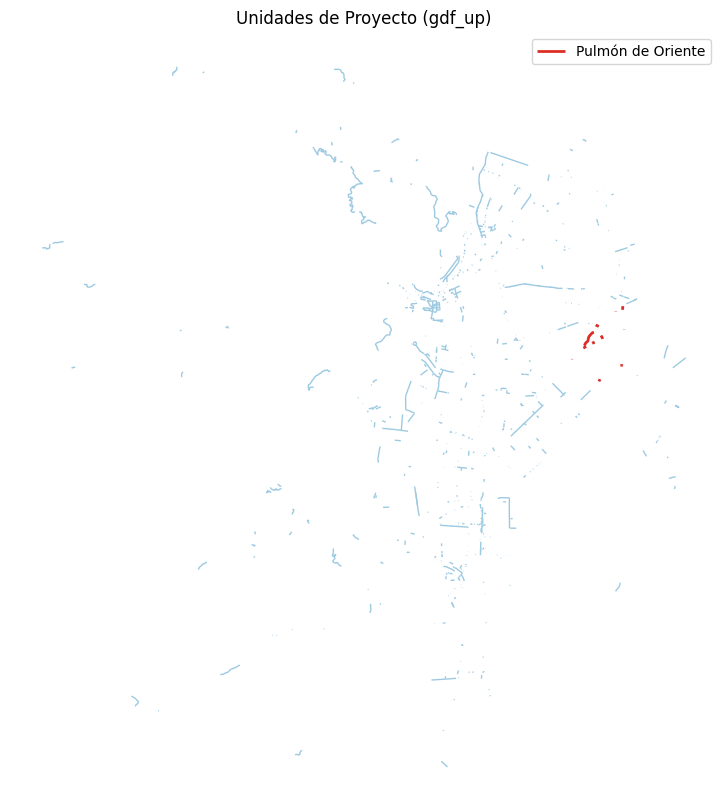

In [50]:
# Graficar gdf_up usando la geometría de línea original por UPID
gdf_up_plot = gpd.GeoDataFrame(
    gdf_up.copy(),
    geometry=gdf_up["upid"].map(geom_linea_por_upid),
    crs=gdf_up_geo.crs
)

fig, ax = plt.subplots(figsize=(12, 10))

# Todas las UP
gdf_up_plot.plot(ax=ax, color="#9ecae1", linewidth=1)

# Resaltar las que están en Pulmón de Oriente
mask_pulmon = gdf_up_plot["proyectos_estrategicos"] == "Pulmón de Oriente"
gdf_up_plot[mask_pulmon].plot(ax=ax, color="#de2d26", linewidth=2, label="Pulmón de Oriente")

ax.set_title("Unidades de Proyecto (gdf_up)")
ax.axis("off")
ax.legend()
plt.show()

## IDENTIFICACIÓN DE INTERVENCIONES

In [51]:
# Crear gdf_int con la lógica solicitada (tomando como base gdf_combined)
source_df = gdf_combined.copy()

requested_columns_int = [
    'upid', 'referencia_proceso', 'referencia_contrato', 'bpin', 'identificador', 'fuente_financiacion',
    'tipo_intervencion', 'unidad', 'cantidad', 'estado', 'presupuesto_base', 'avance_obra', 'fecha_inicio',
    'fecha_fin', 'fecha_inauguracion', 'url_proceso', 'descripcion_intervencion', 'observaciones',
    'nombre_centro_gestor', 'clase_up'
]

# Filtrar solo columnas existentes
available_columns_int = [col for col in requested_columns_int if col in source_df.columns]
missing_columns_int = [col for col in requested_columns_int if col not in source_df.columns]

gdf_int = source_df[available_columns_int].copy()

# Crear intervencion_id con contador reiniciado por cada UPID
gdf_int['intervencion_id'] = gdf_int.groupby('upid').cumcount() + 1
gdf_int['intervencion_id'] = gdf_int['upid'] + '-INT-' + gdf_int['intervencion_id'].astype(str)

# Reordenar columnas para dejar intervencion_id después de upid
cols = ['upid', 'intervencion_id'] + [col for col in gdf_int.columns if col not in ['upid', 'intervencion_id']]
gdf_int = gdf_int[cols]

print("Columnas faltantes:", missing_columns_int)
gdf_int.head()

Columnas faltantes: []


,upid,intervencion_id,referencia_proceso,referencia_contrato,bpin,identificador,fuente_financiacion,tipo_intervencion,unidad,cantidad,...,presupuesto_base,avance_obra,fecha_inicio,fecha_fin,fecha_inauguracion,url_proceso,descripcion_intervencion,observaciones,nombre_centro_gestor,clase_up
0,UNP-1517,UNP-1517-INT-1,None,None,2.023760e+12,Grupo Operativo,None,Recarpeteo,m,121.0,...,9.123318e+07,100.0,NaT,NaT,None,None,None,None,Secretaría de Infraestructura,Obra vial
1,UNP-1518,UNP-1518-INT-1,None,None,2.023760e+12,Grupo Operativo,None,Recarpeteo,m,147.0,...,1.108370e+08,100.0,NaT,NaT,None,None,None,None,Secretaría de Infraestructura,Obra vial
2,UNP-1519,UNP-1519-INT-1,None,None,2.023760e+12,Grupo Operativo,None,Recarpeteo,m,128.0,...,9.651113e+07,100.0,NaT,NaT,None,None,None,None,Secretaría de Infraestructura,Obra vial
3,UNP-1520,UNP-1520-INT-1,None,None,2.022760e+12,Grupo Operativo,None,Recarpeteo,m,91.0,...,6.861338e+07,100.0,NaT,NaT,None,None,None,None,Secretaría de Infraestructura,Obra vial
4,UNP-1521,UNP-1521-INT-1,None,None,2.023760e+12,Grupo Operativo,None,Recarpeteo,m,7.6,...,5.730348e+06,100.0,NaT,NaT,None,None,None,None,Secretaría de Infraestructura,Obra vial


## SUBIR UP

In [52]:
import json
import math

COLLECTION_NAME = "unidades_proyecto"

# Reference to the collection
collection_ref = db.collection(COLLECTION_NAME)

# Convert gdf_up to list of dictionaries
records = gdf_up.to_dict('records')

def clean_value(v):
    """Return True if the value is valid (not None, not NaN)."""
    if v is None:
        return False
    if isinstance(v, float) and (pd.isna(v) or math.isnan(v)):
        return False
    return True

def normalize_geometry(geom):
    """
    Convert geometry to a Firestore-compatible map that the frontend's
    parseGeometry utility can read.

    Returns a dict  { "type": str, "coordinates": str }  where:
      - "type"        → RFC 7946 geometry type (LineString, MultiLineString, …)
      - "coordinates" → JSON-serialized coordinate array (string)

    parseGeometry in geometryParser.ts handles:
      1) geometry.type  → must be a first-class Firestore field (not nested in a JSON string)
      2) geometry.coordinates → can be a JSON string; the utility parses it automatically

    Strips the Z coordinate if present so only [lon, lat] pairs are kept.
    """
    if geom is None:
        return None

    # Accept shapely geometries
    if hasattr(geom, '__geo_interface__'):
        geom = geom.__geo_interface__

    # Accept raw JSON strings (re-parse first)
    if isinstance(geom, str):
        try:
            geom = json.loads(geom)
        except (json.JSONDecodeError, TypeError):
            return None

    if not isinstance(geom, dict):
        return None

    geom_type = geom.get("type")
    coords = geom.get("coordinates")

    if not geom_type or coords is None:
        return None

    def strip_z(coord_list):
        """Recursively strip Z values, keeping only [lon, lat]."""
        if isinstance(coord_list, (list, tuple)):
            if len(coord_list) > 0 and isinstance(coord_list[0], (int, float)):
                # Leaf coordinate pair/triple → keep only [lon, lat]
                return [float(coord_list[0]), float(coord_list[1])]
            else:
                return [strip_z(c) for c in coord_list]
        return coord_list

    clean_coords = strip_z(coords)

    # Return a Firestore MAP (dict) with:
    #   - "type"        as a plain string field  (required by parseGeometry)
    #   - "coordinates" as a JSON string         (parseGeometry handles the parsing)
    return {
        "type": geom_type,
        "coordinates": json.dumps(clean_coords, separators=(',', ':'))
    }

# Upload using batches
batch = db.batch()
batch_count = 0
uploaded_count = 0
total = len(records)

for record in records:
    doc_id = record.get("upid", f"doc_{uploaded_count}")
    doc_ref = collection_ref.document(doc_id)

    # Clean record: remove None and NaN values
    clean_record = {k: v for k, v in record.items() if clean_value(v)}

    # Normalize geometry to { type, coordinates } map (RFC 7946 compatible for frontend)
    if "geometry" in clean_record:
        clean_record["geometry"] = normalize_geometry(clean_record["geometry"])
        if clean_record["geometry"] is None:
            del clean_record["geometry"]

    batch.set(doc_ref, clean_record)
    batch_count += 1
    uploaded_count += 1

    if batch_count >= 500:
        try:
            batch.commit()
            print(f"  ↑ Uploaded {uploaded_count}/{total} documents...")
        except Exception as e:
            print(f"  ✗ Error uploading batch: {e}")
            raise
        batch = db.batch()
        batch_count = 0

# Commit remaining documents
if batch_count > 0:
    try:
        batch.commit()
    except Exception as e:
        print(f"  ✗ Error uploading final batch: {e}")
        raise

print(f"✓ Successfully uploaded {uploaded_count} documents to '{COLLECTION_NAME}' collection")


  ↑ Uploaded 500/713 documents...
✓ Successfully uploaded 713 documents to 'unidades_proyecto' collection


## SUBIR INTERVENCIONES

In [53]:
# Crear gdf_int con la lógica solicitada (tomando como base gdf_combined)
requested_columns_int = [
    'upid', 'referencia_proceso', 'referencia_contrato', 'bpin', 'identificador', 'fuente_financiacion',
    'tipo_intervencion', 'unidad', 'cantidad', 'estado', 'presupuesto_base', 'avance_obra', 'fecha_inicio',
    'fecha_fin', 'fecha_inauguracion', 'url_proceso', 'descripcion_intervencion', 'observaciones',
    'nombre_centro_gestor', 'clase_up'
]

# Filtrar solo columnas existentes
available_columns_int = [col for col in requested_columns_int if col in gdf_combined.columns]
missing_columns_int = [col for col in requested_columns_int if col not in gdf_combined.columns]

gdf_int = gdf_combined[available_columns_int].copy()

# Crear intervencion_id con contador reiniciado por cada UPID
gdf_int['intervencion_id'] = gdf_int.groupby('upid').cumcount() + 1
gdf_int['intervencion_id'] = gdf_int['upid'] + '-INT-' + gdf_int['intervencion_id'].astype(str)

# Reordenar columnas para dejar intervencion_id después de upid
cols = ['upid', 'intervencion_id'] + [col for col in gdf_int.columns if col not in ['upid', 'intervencion_id']]
gdf_int = gdf_int[cols]

# Modificar 'estado' basado en 'avance_obra' con excepciones
gdf_int['avance_obra'] = pd.to_numeric(gdf_int['avance_obra'], errors='coerce')

gdf_int['estado'] = gdf_int.apply(lambda row:
    'En alistamiento' if row['avance_obra'] == 0 and row['estado'] != 'Proyectado'
    else 'En ejecución' if 1 <= row['avance_obra'] <= 99 and row['estado'] != 'Suspendido'
    else 'Terminado' if row['avance_obra'] == 100 and row['estado'] != 'Inaugurado'
    else row['estado'],
    axis=1
)

print("Columnas faltantes:", missing_columns_int)
gdf_int.head()

Columnas faltantes: []


,upid,intervencion_id,referencia_proceso,referencia_contrato,bpin,identificador,fuente_financiacion,tipo_intervencion,unidad,cantidad,...,presupuesto_base,avance_obra,fecha_inicio,fecha_fin,fecha_inauguracion,url_proceso,descripcion_intervencion,observaciones,nombre_centro_gestor,clase_up
0,UNP-1517,UNP-1517-INT-1,None,None,2.023760e+12,Grupo Operativo,None,Recarpeteo,m,121.0,...,9.123318e+07,100.0,NaT,NaT,None,None,None,None,Secretaría de Infraestructura,Obra vial
1,UNP-1518,UNP-1518-INT-1,None,None,2.023760e+12,Grupo Operativo,None,Recarpeteo,m,147.0,...,1.108370e+08,100.0,NaT,NaT,None,None,None,None,Secretaría de Infraestructura,Obra vial
2,UNP-1519,UNP-1519-INT-1,None,None,2.023760e+12,Grupo Operativo,None,Recarpeteo,m,128.0,...,9.651113e+07,100.0,NaT,NaT,None,None,None,None,Secretaría de Infraestructura,Obra vial
3,UNP-1520,UNP-1520-INT-1,None,None,2.022760e+12,Grupo Operativo,None,Recarpeteo,m,91.0,...,6.861338e+07,100.0,NaT,NaT,None,None,None,None,Secretaría de Infraestructura,Obra vial
4,UNP-1521,UNP-1521-INT-1,None,None,2.023760e+12,Grupo Operativo,None,Recarpeteo,m,7.6,...,5.730348e+06,100.0,NaT,NaT,None,None,None,None,Secretaría de Infraestructura,Obra vial


In [54]:
gdf_int.columns

Index(['upid', 'intervencion_id', 'referencia_proceso', 'referencia_contrato',
       'bpin', 'identificador', 'fuente_financiacion', 'tipo_intervencion',
       'unidad', 'cantidad', 'estado', 'presupuesto_base', 'avance_obra',
       'fecha_inicio', 'fecha_fin', 'fecha_inauguracion', 'url_proceso',
       'descripcion_intervencion', 'observaciones', 'nombre_centro_gestor',
       'clase_up'],
      dtype='object')

In [55]:
gdf_int['estado']

0      Terminado
1      Terminado
2      Terminado
3      Terminado
4      Terminado
         ...    
708    Terminado
709    Terminado
710    Terminado
711    Terminado
712    Terminado
Name: estado, Length: 713, dtype: object

In [56]:
import math

COLLECTION_INT_NAME = "intervenciones_unidades_proyecto"

collection_int_ref = db.collection(COLLECTION_INT_NAME)

records_int = gdf_int.to_dict('records')

def clean_value_int(v):
    """Return True if the value is valid (not None, not NaN, not NaT)."""
    if v is None:
        return False
    if isinstance(v, float) and (pd.isna(v) or math.isnan(v)):
        return False
    try:
        if pd.isnull(v):
            return False
    except (TypeError, ValueError):
        pass
    return True

batch_int = db.batch()
batch_count_int = 0
uploaded_count_int = 0
total_int = len(records_int)

for record in records_int:
    doc_id = record.get('intervencion_id', f'doc_{uploaded_count_int}')
    doc_ref = collection_int_ref.document(doc_id)

    clean_record = {k: v for k, v in record.items() if clean_value_int(v)}

    # Convertir timestamps/fechas a string ISO para compatibilidad con Firestore
    for key, val in clean_record.items():
        if hasattr(val, 'isoformat'):
            clean_record[key] = val.isoformat()

    batch_int.set(doc_ref, clean_record)
    batch_count_int += 1
    uploaded_count_int += 1

    if batch_count_int >= 500:
        try:
            batch_int.commit()
            print(f"  ↑ Uploaded {uploaded_count_int}/{total_int} documents...")
        except Exception as e:
            print(f"  ✗ Error uploading batch: {e}")
            raise
        batch_int = db.batch()
        batch_count_int = 0

if batch_count_int > 0:
    try:
        batch_int.commit()
    except Exception as e:
        print(f"  ✗ Error uploading final batch: {e}")
        raise

print(f"✓ Successfully uploaded {uploaded_count_int} documents to '{COLLECTION_INT_NAME}' collection")

  ↑ Uploaded 500/713 documents...
✓ Successfully uploaded 713 documents to 'intervenciones_unidades_proyecto' collection




## EXPORTACIÓN DE GEOJSON PRELIMINAR

In [57]:
#gdf_combined.to_file("app_outputs/unidades_proyecto_infraestructura_outputs/unidades_proyecto_infraestructura_2024_2025.geojson", driver='GeoJSON')